# Amazon Product Review Sentiment Analysis

This notebook loads the review dataset, converts star ratings into binary sentiment labels, trains a baseline text classifier, evaluates it, and tests custom reviews.

In [3]:
from pathlib import Path
import re

import joblib
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 120)
np.random.seed(42)


In [4]:
ROOT = Path.cwd()
DATA_PATH = ROOT / 'data' / '20191226-reviews.csv'

df = pd.read_csv(DATA_PATH)
df.head()


,asin,name,rating,date,verified,title,body,helpfulVotes
0,B0000SX2UC,Janet,3,"October 11, 2005",False,"Def not best, but not worst",I had the Samsung A600 for awhile which is absolute doo doo. You can read my review on it and detect my rage at the ...,1.0
1,B0000SX2UC,Luke Wyatt,1,"January 7, 2004",False,Text Messaging Doesn't Work,Due to a software issue between Nokia and Sprint this phone's text messaging capabilities don't work with Sprint's s...,17.0
2,B0000SX2UC,Brooke,5,"December 30, 2003",False,Love This Phone,"This is a great, reliable phone. I also purchased this phone after my samsung A460 died. The menu is easily comprehe...",5.0
3,B0000SX2UC,amy m. teague,3,"March 18, 2004",False,"Love the Phone, BUT...!","I love the phone and all, because I really did need one, but I didn't expect the price of the bill when I received o...",1.0
4,B0000SX2UC,tristazbimmer,4,"August 28, 2005",False,"Great phone service and options, lousy case!","The phone has been great for every purpose it offers, except the day i bought it-i couldnt get the case off. You can...",1.0


In [5]:
print('Columns:', df.columns.tolist())
print('\nRating distribution:')
print(df['rating'].value_counts().sort_index())

print('\nSample rows:')
display(df[['rating', 'title', 'body']].head(3))


Columns: ['asin', 'name', 'rating', 'date', 'verified', 'title', 'body', 'helpfulVotes']

Rating distribution:
rating
1    12743
2     3915
3     4752
4     8824
5    37752
Name: count, dtype: int64

Sample rows:


,rating,title,body
0,3,"Def not best, but not worst",I had the Samsung A600 for awhile which is absolute doo doo. You can read my review on it and detect my rage at the ...
1,1,Text Messaging Doesn't Work,Due to a software issue between Nokia and Sprint this phone's text messaging capabilities don't work with Sprint's s...
2,5,Love This Phone,"This is a great, reliable phone. I also purchased this phone after my samsung A460 died. The menu is easily comprehe..."


In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r"[^a-z\s']", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


data = df[['body', 'rating']].copy()
data['body'] = data['body'].fillna('').astype(str)
data['rating'] = pd.to_numeric(data['rating'], errors='coerce')
data = data.dropna(subset=['body', 'rating'])
data = data[data['rating'] != 3].copy()
data['sentiment'] = (data['rating'] >= 4).astype(int)
data['text'] = data['body'].apply(clean_text)
data = data[['text', 'sentiment']].reset_index(drop=True)

print('Clean dataset shape:', data.shape)
print('\nSentiment balance:')
print(data['sentiment'].value_counts())


Clean dataset shape: (63234, 2)

Sentiment balance:
sentiment
1    46576
0    16658
Name: count, dtype: int64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    data['text'],
    data['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=data['sentiment'],
)

print('Train size:', X_train.shape[0])
print('Test size :', X_test.shape[0])


Train size: 50587
Test size : 12647


In [8]:
model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2), stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
])

model


,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [9]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Test accuracy: {accuracy:.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


Test accuracy: 0.9092

Classification report:
              precision    recall  f1-score   support

    Negative       0.78      0.92      0.84      3332
    Positive       0.97      0.90      0.94      9315

    accuracy                           0.91     12647
   macro avg       0.87      0.91      0.89     12647
weighted avg       0.92      0.91      0.91     12647



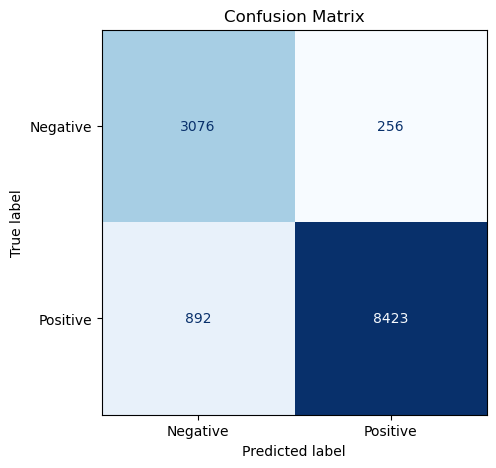

In [10]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix')
plt.show()


In [11]:
def predict_review(review):
    prob = model.predict_proba([clean_text(review)])[0][1]
    label = 'Positive' if prob >= 0.5 else 'Negative'
    confidence = prob if label == 'Positive' else 1 - prob
    print(f'Review     : {review}')
    print(f'Prediction : {label}')
    print(f'Confidence : {confidence:.2%}')
    print('-')


predict_review('This product is amazing and works exactly as expected.')
predict_review('Terrible quality, waste of money, and it stopped working quickly.')
predict_review('It is okay, nothing special but not bad either.')


Review     : This product is amazing and works exactly as expected.
Prediction : Positive
Confidence : 98.45%
-
Review     : Terrible quality, waste of money, and it stopped working quickly.
Prediction : Negative
Confidence : 99.71%
-
Review     : It is okay, nothing special but not bad either.
Prediction : Negative
Confidence : 62.41%
-


In [12]:
MODELS_DIR = ROOT / 'models'
RESULTS_DIR = ROOT / 'results'
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

joblib.dump(model, MODELS_DIR / 'amazon_sentiment_model.joblib')
print('Saved model to models/amazon_sentiment_model.joblib')


Saved model to models/amazon_sentiment_model.joblib
